# Notebook 7 — When one number isn't enough

*SWC ENC 2026 · behaviour module*

This is where the day has been heading. Every mouse so far held a **fixed**
strategy. Real mice drift — and so does our dynamic mouse, sliding from
visual-dominant to timing-dominant across the session. A single static fit can't
express that. We'll build the paper's answer, the **dynamic logistic regression**
of Piet et al. (their Figure 1D), in small steps:

1. Watch the static fit fail, then patch it with **sliding windows**.
2. Replace the patch with a principled model: a **random-walk prior** on the weights.
3. Write down its objective, fit it, and **recover the drifting strategy**.
4. Understand the smoothing parameter $\sigma$ as the dial between static and noisy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import swcbehav as sb

def get_Xy(sess):
    X, cols = sb.build_design_matrix(sess.table)
    y = sess.table["bout_start"].to_numpy().astype(float)
    return X, y, cols

dyn = sb.make_mouse("dynamic", n_images=2500, seed=1)
X, y, cols = get_Xy(dyn)
T, K = X.shape
print(f"dynamic mouse: {T} images, {K} strategies")

dynamic mouse: 2500 images, 5 strategies


## The problem: one static fit can't move

Fit the static model (Notebook 3) to the dynamic mouse and overlay it on the true
weights. The fit is a flat compromise slicing through weights that are visibly
moving.

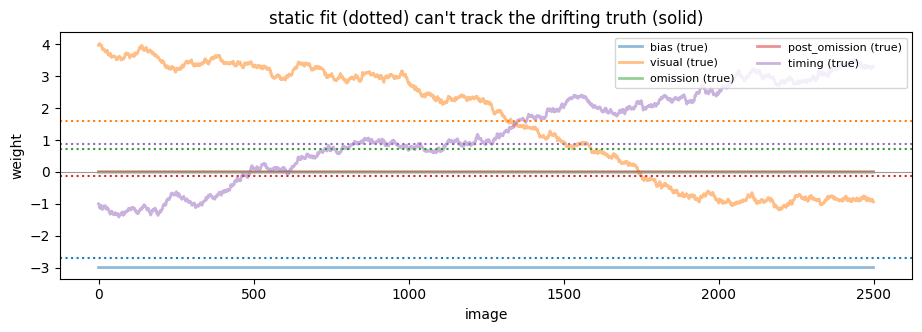

In [2]:
w_static = sb.fit_static(X, y)
sb.plotting.plot_weights(true_weights=dyn.true_weights, col_names=cols)
for k in range(K):
    plt.axhline(w_static[k], color=plt.cm.tab10(k), ls=":", lw=1.5)
plt.title("static fit (dotted) can't track the drifting truth (solid)")
plt.show()

## Step 1 — a naive patch: sliding windows

If the strategy changes slowly, maybe we can fit the *static* model **locally** —
in a short window around each time point — and let the window slide. Then the
weights are allowed to differ at different times.

**Exercise 1.** Complete `sliding_window_fit`: at each window center, fit the
static model to just the images inside a window of half-width `half`.

In [3]:
def sliding_window_fit(X, y, centers, half=150):
    W = np.zeros((len(centers), X.shape[1]))
    for i, c in enumerate(centers):
        lo, hi = max(0, c - half), min(len(y), c + half)
        W[i] = sb.fit_static(X[lo:hi], y[lo:hi])
    return W

centers = np.arange(0, T, 100)
W_win = sliding_window_fit(X, y, centers)

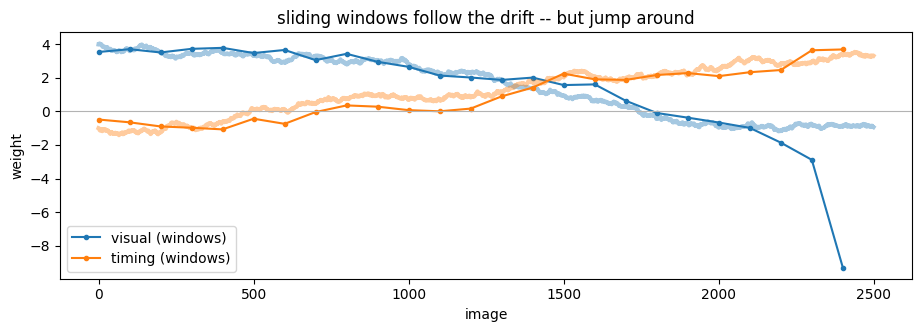

In [4]:
plt.figure(figsize=(11, 3.2))
for k, name in [(1, "visual"), (4, "timing")]:
    line, = plt.plot(centers, W_win[:, k], "o-", ms=3, label=f"{name} (windows)")
    plt.plot(dyn.true_weights[:, k], color=line.get_color(), alpha=0.4, lw=3)
plt.axhline(0, color="0.7", lw=0.8); plt.xlabel("image"); plt.ylabel("weight")
plt.title("sliding windows follow the drift -- but jump around"); plt.legend()
plt.show()

Better! The window weights *do* follow the true drift (thick pale lines). But
they're jumpy: each window is fit independently on only a few hundred images, so
noise makes neighboring windows disagree more than the animal actually changed.
And we had to pick a window width by hand. We want the *smoothness* to come from a
principled assumption, not an arbitrary window.

## Step 2 — the random-walk prior

Here's the assumption the paper makes. Instead of fitting each time point
independently, state that the weights **evolve gradually**:

$$w_{t+1} = w_t + \eta_t, \qquad \eta_t \sim \mathcal{N}(0, \sigma^2 I).$$

Each image's weights are a small random step from the previous image's. As a
prior, this says a trajectory is *a priori* more probable when consecutive weights
are close — it **penalizes big jumps**. The negative-log of that prior is exactly
a smoothness penalty:

$$\text{penalty}(W) = \frac{1}{2\sigma^2}\sum_{t=1}^{T-1}\lVert w_{t+1} - w_t\rVert^2 .$$

$\sigma$ controls how much drift we expect per image: small $\sigma$ forbids
change, large $\sigma$ permits it.

## Step 3 — the objective

Fitting means finding the whole weight trajectory $W$ (a $T \times K$ array) that
best trades off **fitting the licks** against **staying smooth**. So we minimize

$$\underbrace{-\sum_t \big[y_t z_t - \log(1+e^{z_t})\big]}_{\text{data: each image uses its own } w_t}
\;+\; \underbrace{\frac{1}{2\sigma^2}\sum_t \lVert w_{t+1}-w_t\rVert^2}_{\text{random-walk prior}},
\qquad z_t = w_t \cdot x_t .$$

The data term is the same Bernoulli likelihood as Notebook 3 — only now each
image has its *own* weights. We supply the gradient too, so the optimizer is
fast. The data-term gradient is the familiar logistic $(p_t - y_t)\,x_t$; the
penalty's gradient is the discrete second difference $w_{t-1} - 2w_t + w_{t+1}$.

**Exercise 2.** Fill in the two random-walk pieces — the penalty **value** and its
contribution to the **gradient**. Everything else (the data term and its
gradient, carried over from Notebook 3) is provided.

In [5]:
def dynamic_objective(W_flat, X, y, sigma):
    T, K = X.shape
    W = W_flat.reshape(T, K)
    z = np.sum(W * X, axis=1)                      # w_t . x_t for every image
    data = -np.sum(y * z - np.logaddexp(0.0, z))   # Bernoulli NLL (from NB3)
    grad = (sb.sigmoid(z) - y)[:, None] * X        # data-term gradient (from NB3)

    D = np.diff(W, axis=0)                          # w_{t+1} - w_t
    penalty = np.sum(D * D) / (2 * sigma ** 2)      # <-- random-walk prior
    gp = np.zeros_like(W)                           # <-- its gradient (2nd difference)
    gp[:-1] -= D
    gp[1:] += D
    grad += gp / sigma ** 2

    return data + penalty, grad.ravel()

## Step 4 — fit it

The objective is convex, so we just hand it to L-BFGS. Two practical touches: we
pass `jac=True` because our function returns the gradient, and we **warm-start**
from the static fit (copied to every time point) so the optimizer starts from a
sensible flat trajectory.

**Exercise 3.** Complete `fit_dynamic`.

In [6]:
def fit_dynamic(X, y, sigma=0.05):
    T, K = X.shape
    w_init = np.tile(sb.fit_static(X, y), (T, 1)).ravel()   # warm start: static everywhere
    res = minimize(dynamic_objective, w_init, args=(X, y, sigma),
                   jac=True, method="L-BFGS-B", options={"maxiter": 500})
    return res.x.reshape(T, K)

W_dyn = fit_dynamic(X, y, sigma=0.05)

## Step 5 — recover the drifting strategy

The payoff. Overlay the recovered trajectory (dashed) on the true weights (solid).
This is Figure 1D — reconstructed from scratch.

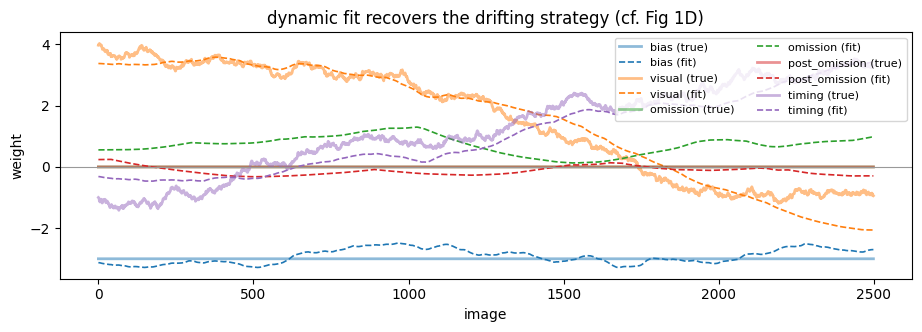

visual : corr(recovered, true) = 0.97
timing : corr(recovered, true) = 0.96


In [7]:
sb.plotting.plot_weights(true_weights=dyn.true_weights, fit_weights=W_dyn, col_names=cols)
plt.title("dynamic fit recovers the drifting strategy (cf. Fig 1D)")
plt.show()

for k, name in [(1, "visual"), (4, "timing")]:
    r = np.corrcoef(W_dyn[:, k], dyn.true_weights[:, k])[0, 1]
    print(f"{name:7s}: corr(recovered, true) = {r:.2f}")

The dashed estimates ride right on top of the true drift: the visual weight falls,
the timing weight rises, and the crossover — the moment the mouse's dominant
strategy flips — is recovered without ever seeing the truth. We can also confirm
the fit predicts the *behavior*: smoothed model licking probability tracks the
smoothed data.

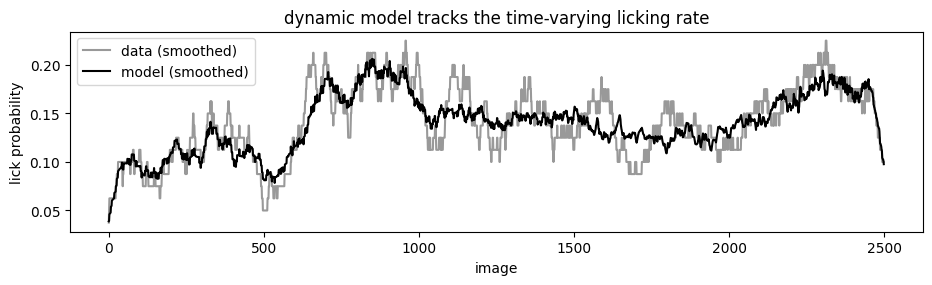

In [8]:
p_model = sb.sigmoid(np.sum(W_dyn * X, axis=1))
box = np.ones(80) / 80
sm = lambda v: np.convolve(v, box, mode="same")
plt.figure(figsize=(11, 2.6))
plt.plot(sm(y), color="0.6", label="data (smoothed)")
plt.plot(sm(p_model), color="k", label="model (smoothed)")
plt.xlabel("image"); plt.ylabel("lick probability"); plt.legend()
plt.title("dynamic model tracks the time-varying licking rate")
plt.show()

## Step 6 — the smoothing dial $\sigma$

$\sigma$ sets how much drift the prior allows per image. It interpolates between
the two models we already know:

* **small $\sigma$** — jumps are heavily penalized, so the trajectory is nearly
  flat: we recover the **static fit** (Notebook 3).
* **large $\sigma$** — jumps are cheap, so the trajectory chases noise, like the
  **sliding windows**.
* **in between** — it recovers the true drift.

Because this is synthetic data, we can see the sweet spot directly: plot the
recovery error against the true trajectory as $\sigma$ varies — a bias–variance
U-curve with its minimum near the $\sigma$ that generated the data. (On real data
you'd instead choose $\sigma$ by cross-validation or model evidence, as the paper
does in Figure 2C.)

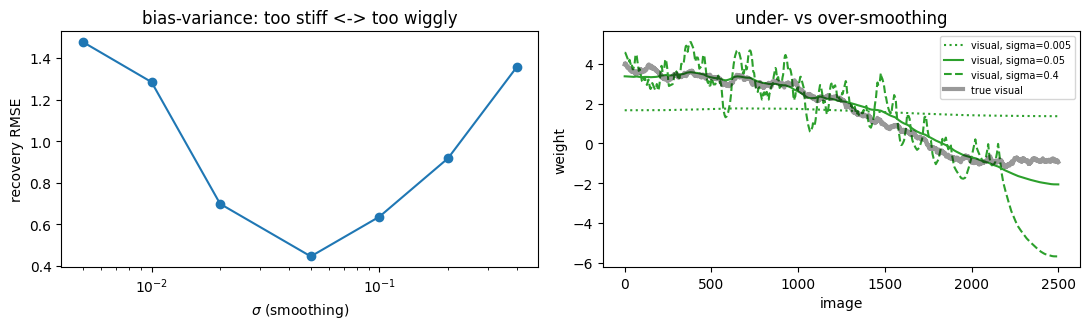

In [9]:
sigmas = np.array([0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.4])
rmse = []
truth = dyn.true_weights[:, [1, 4]]
for s in sigmas:
    W = fit_dynamic(X, y, sigma=s)
    rmse.append(np.sqrt(np.mean((W[:, [1, 4]] - truth) ** 2)))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].semilogx(sigmas, rmse, "o-")
ax[0].set_xlabel(r"$\sigma$ (smoothing)"); ax[0].set_ylabel("recovery RMSE")
ax[0].set_title("bias-variance: too stiff <-> too wiggly")
for s, ls in [(0.005, ":"), (0.05, "-"), (0.4, "--")]:
    W = fit_dynamic(X, y, sigma=s)
    ax[1].plot(W[:, 1], ls, color="tab:green", label=f"visual, sigma={s}")
ax[1].plot(truth[:, 0], color="k", alpha=0.4, lw=3, label="true visual")
ax[1].set_xlabel("image"); ax[1].set_ylabel("weight")
ax[1].set_title("under- vs over-smoothing"); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

## Wrap-up — the whole day in one picture

You built the paper's **dynamic logistic regression** from its pieces: a
per-image logistic likelihood (Notebook 3), a random-walk prior that ties
neighboring time points together, and a smoothing parameter $\sigma$ that dials
continuously between the static fit and the raw sliding-window estimate. Fit to
the dynamic mouse, it recovers a *changing* strategy — the crossover the static
model was blind to.

That's the arc of Figures 1–2: quantify licking with a design matrix, fit
strategy weights, evaluate and ablate them, and let them drift over time.

**Optional (Notebook 8):** Figure 3 — showing that a mouse's *engagement* is a
separate axis from its *strategy*, cleanly separable because we generated them
independently.